In [20]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "matplotlib>=3.7" "statsmodels==0.14.6"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
import warnings                                   # 검정 함수의 경고는 결론을 읽는 근거라 남긴다
warnings.simplefilter("ignore", FutureWarning)    # 버전 안내만 끈다
warnings.simplefilter("ignore", DeprecationWarning)
warnings.filterwarnings("ignore", "Glyph")        # 폰트에 없는 글자 안내

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 기준선=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다

import matplotlib.dates as mdates


def datefmt(ax, fmt="%m-%d", n=5):
    """시간 축 눈금 개수와 표기를 잡아 날짜 라벨이 겹치지 않게 한다"""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=n))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


print("사용 폰트:", FONT, "| 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다")

사용 폰트: DejaVu Sans | 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다


In [21]:
# ===== 한글 폰트 설정 =====
font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

In [22]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 변수를 직접 만듭니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 왼쪽 파일 탐색기에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요

raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간 — 시차 24 가 "24시간 전" 이라는 뜻이 된다

_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다 (요일 효과를 지키려고)
_y = _y.fillna(_y.shift(-24 * 7))         # 1주일 전도 휴무인 시각만 1주일 뒤 값으로
df["demand"] = _y                         # 보정 계열 — 모형 학습이 쓸 열 (원본 count 는 그대로 둔다)
df["is_imputed"] = df["functioning"].eq("No")

hourly_c = df["count"].astype(float)      # 쓸 변수 1 — 원본 시간 계열 1년 8,760시간 (대/시간)
daily_c = df["count"].resample("D").sum()  # 쓸 변수 2 — 하루 합계로 만든 일 계열 365일 (대/일)

print(f"행 x 열 : {df.shape[0]:,} x {df.shape[1]}   기간 {df.index.min()} ~ {df.index.max()}")
print(f"시각 간격 종류 {dict(df.index.to_series().diff().value_counts())}  "
      f"(한 종류면 빠진 시각 없음) · 중복 시각 {int(df.index.duplicated().sum())}건")
print(f"원본 count 평균 {df['count'].mean():.2f} 대/시간  →  "
      f"보정 demand 평균 {df['demand'].mean():.2f} 대/시간")
print(f"채운 시간 {int(df['is_imputed'].sum())}시간 / "
      f"{df.index[df['is_imputed']].normalize().nunique()}일   "
      f"보정 계열 결측 {int(df['demand'].isna().sum())}건")
print(f"시간 계열 {len(hourly_c):,}시간 (그중 휴무 {int(df['is_imputed'].sum())}시간)"
      f" · 일 계열 {len(daily_c)}일")
print("쓸 수 있는 이름 : df (표 전체) · df['count'] (원본 대여 수요, 대) · df['demand'] (보정 수요, 대)"
      " · hourly_c (원본 시간 계열, 대/시간) · daily_c (하루 합계 일 계열, 대/일)")

행 x 열 : 8,760 x 16   기간 2017-12-01 00:00:00 ~ 2018-11-30 23:00:00
시각 간격 종류 {Timedelta('0 days 01:00:00'): np.int64(8759)}  (한 종류면 빠진 시각 없음) · 중복 시각 0건
원본 count 평균 704.60 대/시간  →  보정 demand 평균 737.85 대/시간
채운 시간 295시간 / 13일   보정 계열 결측 0건
시간 계열 8,760시간 (그중 휴무 295시간) · 일 계열 365일
쓸 수 있는 이름 : df (표 전체) · df['count'] (원본 대여 수요, 대) · df['demand'] (보정 수요, 대) · hourly_c (원본 시간 계열, 대/시간) · daily_c (하루 합계 일 계열, 대/일)


계절 강도 — 시간 계열 8,760시간 · 주기 24: 0.5715
계절 강도 — 일 계열 365일 · 주기 7: 0.0894
주기 24는 시간 단위에서 계열의 57.15%를, 주기 7은 일 단위에서 계열의 8.94%를 설명합니다.


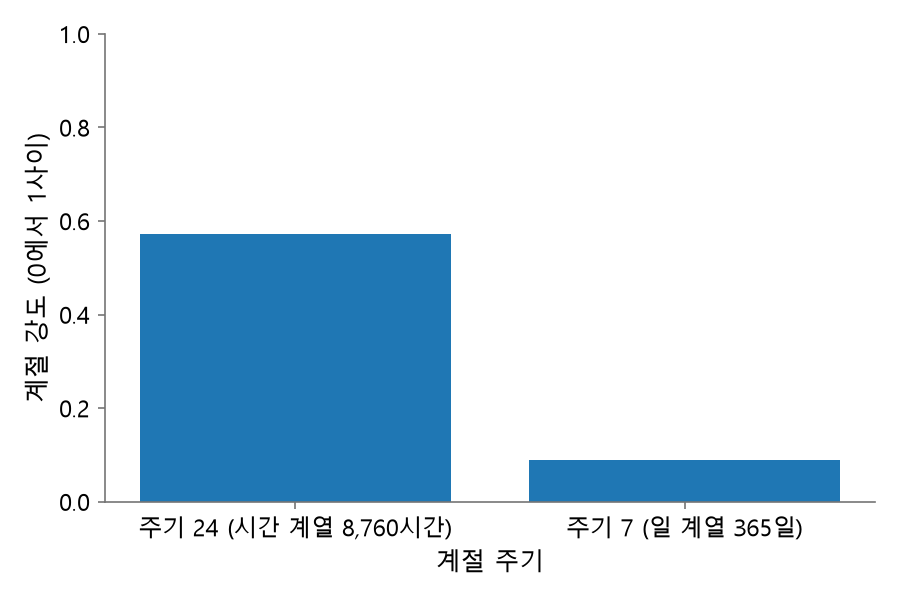

In [23]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
배치 기준을 요일에 둘지 시각에 둘지 정해야해 그래서 주기24와 주기7을 비교해서 확인해야해
1. 계절 강도 - 시간 계열 8760시간 주기 24: 무차원, 소수점 아래 4자리(hourly_c)
계절 강도
STL 분해
2. 계절 강도 - 일 계열 365일 주기 7: 무차원, 소수점 아래 4자리(daily_c)
3. 추가 행: 두 값을 각각 집계 단위에서 그 주기가 설명한 비중으로 읽은 한 행
4. 그래프(막대)
막대 2개 이름은 주기 24 (시간 계얄 8,760시간), 주기 7 (일 계열 365일)
막대 이름에서 계열 이름은 빼지 않음
세로축 범위 0~1
가로축 이름: 계절 주기
세로축 이름: 계절 강도 (0에서 1사이)
"""
# --- 여기부터 AI 코드 ---
from statsmodels.tsa.seasonal import STL
import numpy as np
import matplotlib.pyplot as plt

def seasonal_strength(series, period):
    stl = STL(series, period=period, robust=True)
    res = stl.fit()
    resid_var = np.var(res.resid)
    seasonal_resid_var = np.var(res.seasonal + res.resid)
    return round(max(0, 1 - resid_var / seasonal_resid_var), 4)

strength_24 = seasonal_strength(hourly_c, 24)
strength_7 = seasonal_strength(daily_c, 7)

print(f"계절 강도 — 시간 계열 8,760시간 · 주기 24: {strength_24:.4f}")
print(f"계절 강도 — 일 계열 365일 · 주기 7: {strength_7:.4f}")
print(f"주기 24는 시간 단위에서 계열의 {strength_24*100:.2f}%를, "
      f"주기 7은 일 단위에서 계열의 {strength_7*100:.2f}%를 설명합니다.")

labels = ["주기 24 (시간 계열 8,760시간)", "주기 7 (일 계열 365일)"]
values = [strength_24, strength_7]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.ylim(0, 1)
plt.xlabel("계절 주기")
plt.ylabel("계절 강도 (0에서 1사이)")
plt.show()

In [24]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                 # 이 미션만 따로 열어도 이 셀만으로 실행됩니다
    URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
    raw = pd.read_csv(URL, encoding="cp1252", compression="zip")      # 8,760행 x 14열
    #  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 왼쪽 파일 탐색기에 올린 뒤
    #  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
    raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",   # 위치 기반 리네임
                   "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
    raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")   # 01/12/2017 = 2017년 12월 1일
                       + pd.to_timedelta(raw["hour"], unit="h"))
    df = raw.sort_values("datetime").set_index("datetime")
    df.index.freq = "h"                   # 등간격 1시간 — 시차 24 가 "24시간 전" 이라는 뜻이 된다

ALPHA = 0.05                              # 유의수준 — 두 검정에 같은 값을 씁니다
hourly_c = df["count"].astype(float)      # 쓸 변수 1 — 원본 시간 계열 (대/시간)
daily_c = df["count"].resample("D").sum()  # 쓸 변수 2 — 하루 합계로 만든 일 계열 (대/일)

print(f"시간 계열 {len(hourly_c):,}개  평균 {hourly_c.mean():.1f} 대/시간  "
      f"표준편차 {hourly_c.std():.1f}")
print(f"일 계열   {len(daily_c):,}개  평균 {daily_c.mean():,.1f} 대/일  "
      f"표준편차 {daily_c.std():,.1f}")
print(f"유의수준 ALPHA = {ALPHA}")
print()
print("ADF  귀무가설: 단위근이 있다(비정상)  → p < ALPHA 면 기각 = 정상 쪽 증거")
print("KPSS 귀무가설: 정상이다              → p < ALPHA 면 기각 = 비정상 쪽 증거")
print("쓸 수 있는 이름 : df (표 전체) · hourly_c (원본 시간 계열, 대/시간)"
      " · daily_c (일 계열, 대/일) · ALPHA (유의수준)")

시간 계열 8,760개  평균 704.6 대/시간  표준편차 645.0
일 계열   365개  평균 16,910.4 대/일  표준편차 10,258.6
유의수준 ALPHA = 0.05

ADF  귀무가설: 단위근이 있다(비정상)  → p < ALPHA 면 기각 = 정상 쪽 증거
KPSS 귀무가설: 정상이다              → p < ALPHA 면 기각 = 비정상 쪽 증거
쓸 수 있는 이름 : df (표 전체) · hourly_c (원본 시간 계열, 대/시간) · daily_c (일 계열, 대/일) · ALPHA (유의수준)


ADF 검정통계량 — 원본 시간 계열 = -6.9470   p값 = 9.915e-10   → 귀무가설(단위근이 있다)을 기각 → 정상
KPSS 검정통계량 — 원본 시간 계열 = 8.0051   p값 = 0.01   → 귀무가설(정상성이다)을 기각 → 비정상 쪽 증거
계절차분 횟수 D = 1 회
최종 결론 : 비정상 — 계절차분이 필요합니다


C:\Users\pyostry\AppData\Local\Temp\ipykernel_33528\1745496305.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat_kpss, p_kpss = kpss(x, regression="c", nlags="auto")[:2]


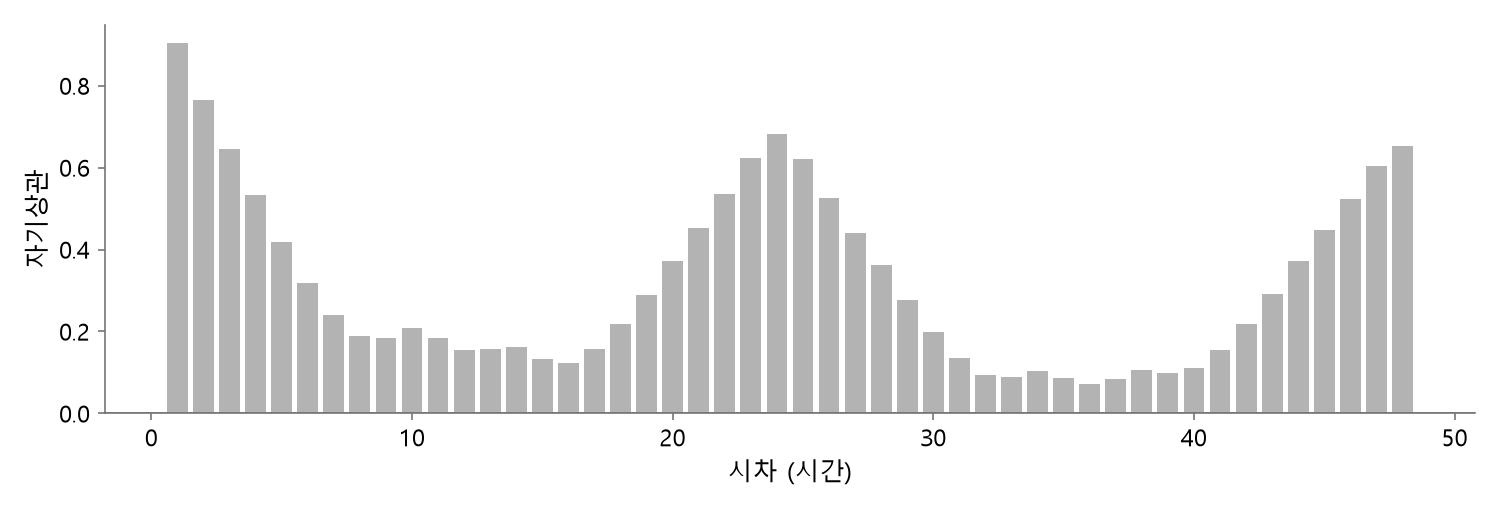

In [25]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다 — 아래는 전임 담당자가 남긴 코드라 돌아가지만 답이 틀렸습니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 튜터가 AI 코드 행 아래를 다시 씁니다.
PROMPT = """
아래 전임자 남긴 코드를 수정해야해
내가 코드를 확인했을 땐 ADF와 KPSS 모두 P-value가 0.05보다 낮다면 정상, 높으면 비정상으로 한 것 같아
ADF는 귀무가설이 정상성이 아니다(단위근이 있다)이기 때문에 0.05보다 낮다면 정상이 나오고 KPSS가 비정상으로 나오게 수정해야할거 같아
내가 추측한 내용이 맞는지 확인해주고 아래 기재한 내용 출력할 수 있도록 코드 짜줘
1. ADF 검정통계량 - 원본 시간 계열: 무차원, 소수점 아래 4자리, 시간당 수요(hourly_c)
2. KPSS 검정통계량 - 원본 시간 계열: 무차원, 소수점 아래 4자리, 같은 계열에 적용한 값
3. 계절차분 횟수 D: 단위 회, 정수
4. 그래프
전임 코드가 그린 시차 1부터 48까지의 자기상관 막대 48개 유지
"""
# --- 여기부터 AI 코드 ---
def is_stationary(x, alpha=ALPHA):
    stat_adf, p_adf = adfuller(x, autolag="AIC")[:2]
    stat_kpss, p_kpss = kpss(x, regression="c", nlags="auto")[:2]

    if p_adf < alpha:
        verdict_adf = "정상"
        phrase_adf = "귀무가설(단위근이 있다)을 기각 → 정상"
    else:
        verdict_adf = "비정상"
        phrase_adf = "귀무가설(단위근이 있다)을 기각하지 못함 → 비정상"

    if p_kpss < alpha:
        verdict_kpss = "비정상"
        phrase_kpss = "귀무가설(정상성이다)을 기각 → 비정상 쪽 증거"
    else:
        verdict_kpss = "정상"
        phrase_kpss = "귀무가설(정상성이다)을 기각하지 못함 → 정상 쪽 증거"

    print(f"ADF 검정통계량 — 원본 시간 계열 = {stat_adf:.4f}   p값 = {p_adf:.4g}   → {phrase_adf}")
    print(f"KPSS 검정통계량 — 원본 시간 계열 = {stat_kpss:.4f}   p값 = {p_kpss:.4g}   → {phrase_kpss}")

    return verdict_adf == "정상" and verdict_kpss == "정상"


ok = is_stationary(hourly_c)
D = 0 if ok else 1
print(f"계절차분 횟수 D = {D} 회")
print("최종 결론 :", "정상 — 그대로 모형에 넣어도 됩니다" if ok else "비정상 — 계절차분이 필요합니다")

r = acf(hourly_c, nlags=48)[1:]
fig, ax = plt.subplots(figsize=(FIG_W, 3.4))
ax.bar(np.arange(1, 49), r, color=COL["연회색"], width=0.8)
ax.axhline(0, color=COL["회색"], lw=0.8)
ax.set_xlabel("시차 (시간)")
ax.set_ylabel("자기상관")
plt.show()

In [26]:
# 미션 3 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 3 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                 # 이 미션만 따로 열어도 이 셀만으로 실행됩니다
    URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
    raw = pd.read_csv(URL, encoding="cp1252", compression="zip")      # 8,760행 x 14열
    #  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 왼쪽 파일 탐색기에 올린 뒤
    #  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
    raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",   # 위치 기반 리네임
                   "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
    raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")   # 01/12/2017 = 2017년 12월 1일
                       + pd.to_timedelta(raw["hour"], unit="h"))
    df = raw.sort_values("datetime").set_index("datetime")
    df.index.freq = "h"                   # 등간격 1시간 — 시차 24 가 "24시간 b전" 이라는 뜻이 된다

ALPHA = 0.05                              # 유의수준 — 미션 2 와 같은 값을 씁니다
hourly_c = df["count"].astype(float)      # 쓸 변수 1 — 원본 시간 계열 (대/시간)


def autocorr(x, k):                       # 쓸 변수 2 — 시차 k 자기상관 한 값
    """statsmodels acf 로 시차 0 부터 k 까지를 구한 뒤 k 번째 자리만 돌려줍니다"""
    return float(acf(np.asarray(x, dtype=float), nlags=k)[k])


print(f"시간 계열 {len(hourly_c):,}개  평균 {hourly_c.mean():.1f} 대/시간  "
      f"표준편차 {hourly_c.std():.1f}")
print(f"유의수준 ALPHA = {ALPHA}")
print()
print("KPSS 귀무가설: 정상이다 → 통계량이 5% 임계값 0.463 보다 작으면 기각하지 못한다 = 정상 쪽")
print("검정 도구 : adfuller(계열, autolag=\"AIC\") · kpss(계열, regression=\"c\", nlags=\"auto\")"
      " — 반환값의 첫 값이 통계량")
print("차분 도구 : 계열.diff(k) 는 k 행 전 값을 한 번 뺍니다 — k 를 비우면 1 행(바로 앞 값)이고,")
print("            뺄 상대가 없어 결측으로 남은 맨 앞은 .dropna() 로 뗍니다")
print("쓸 수 있는 이름 : df (표 전체) · hourly_c (원본 시간 계열, 대/시간) · ALPHA (유의수준)"
      " · autocorr(계열, 시차) · acf · adfuller · kpss")

시간 계열 8,760개  평균 704.6 대/시간  표준편차 645.0
유의수준 ALPHA = 0.05

KPSS 귀무가설: 정상이다 → 통계량이 5% 임계값 0.463 보다 작으면 기각하지 못한다 = 정상 쪽
검정 도구 : adfuller(계열, autolag="AIC") · kpss(계열, regression="c", nlags="auto") — 반환값의 첫 값이 통계량
차분 도구 : 계열.diff(k) 는 k 행 전 값을 한 번 뺍니다 — k 를 비우면 1 행(바로 앞 값)이고,
            뺄 상대가 없어 결측으로 남은 맨 앞은 .dropna() 로 뗍니다
쓸 수 있는 이름 : df (표 전체) · hourly_c (원본 시간 계열, 대/시간) · ALPHA (유의수준) · autocorr(계열, 시차) · acf · adfuller · kpss


C:\Users\pyostry\AppData\Local\Temp\ipykernel_33528\2330232932.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_after = kpss(diffc, regression="c", nlags="auto")[0]
C:\Users\pyostry\AppData\Local\Temp\ipykernel_33528\2330232932.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_before = kpss(hourly_c, regression="c", nlags="auto")[0]


계절차분 후 KPSS 검정통계량 = 0.0083
차분 전 KPSS 검정통계량 = 8.0051
계절차분 후 시차 24 자기상관 = -0.4579
차분 전 시차 24 자기상관 = +0.6813
길이 — 원계열 8760시간, 차분 후 계열 8736시간


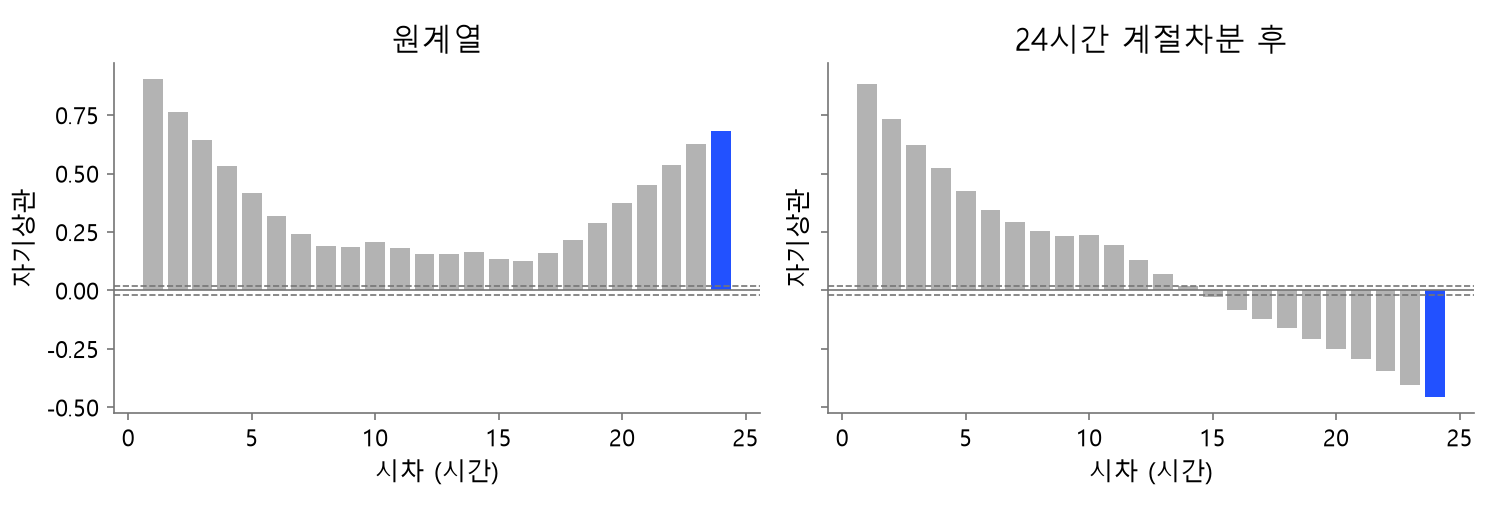

In [27]:
# 미션 3 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
24시간 계절차분을 1회 적용하면 무엇이 달라지는지 확인하려고 해
1. 계절차분 후 KPSS 검정통계량: 무차원, 소수점 아래 4자리, 24시간 계절차분한 계열에 적용한 값
2. 차분 전 KPSS 검정통계량: 같은 자릿수, 시간당 수요 hourly_c에 적용한 값
3. 계절차분 후 시차 24 자기상관: 같은 자릿수, 양수 음수 부호 추가
4. 차분 전 시차 24 자기상관: 3번과 동일 조건
5. 추가 행: 차분한 계열의 길이를 원계열 길이와 함께 기재
6. 그래프(패널 2개)
왼쪽은 원계열이고 제목은 원계열, 오른쪽은 24시간 계절차분한 계열이고 제목은 24시간 계절차분 후
막대는 패널마다 시차 1 부터 최소 24 까지이고, 늘 1 인 시차 0 은 제외
시차 24 막대만 색을 다르게 적용
0 에 가로선 하나와 경계선 ±1.96/√T 위치의 가로 점선 2개 경계선은 자기상관이 0 과 구별되는지 판단하는 기준선이고 이론의 「5. 자기상관과 ACF」가 정의했습니다. 원계열은 8,760시간이라 ±0.021 입니다
가로축 이름: 시차 (시간)
세로축 이름: 자기상관
"""
# --- 여기부터 AI 코드 ---
diffc = hourly_c.diff(24).dropna()

kpss_after = kpss(diffc, regression="c", nlags="auto")[0]
kpss_before = kpss(hourly_c, regression="c", nlags="auto")[0]

ac_after = autocorr(diffc, 24)
ac_before = autocorr(hourly_c, 24)

print(f"계절차분 후 KPSS 검정통계량 = {kpss_after:.4f}")
print(f"차분 전 KPSS 검정통계량 = {kpss_before:.4f}")
print(f"계절차분 후 시차 24 자기상관 = {ac_after:+.4f}")
print(f"차분 전 시차 24 자기상관 = {ac_before:+.4f}")
print(f"길이 — 원계열 {len(hourly_c)}시간, 차분 후 계열 {len(diffc)}시간")

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 3.4), sharey=True)

for ax, series, title in zip(axes, [hourly_c, diffc], ["원계열", "24시간 계절차분 후"]):
    r = acf(series, nlags=24)[1:]
    colors = [COL["연회색"]] * 24
    colors[23] = COL["파랑"]
    bound = 1.96 / np.sqrt(len(series))
    ax.bar(np.arange(1, 25), r, color=colors, width=0.8)
    ax.axhline(0, color=COL["회색"], lw=0.8)
    ax.axhline(bound, color=COL["회색"], lw=0.8, ls="--")
    ax.axhline(-bound, color=COL["회색"], lw=0.8, ls="--")
    ax.set_title(title)
    ax.set_xlabel("시차 (시간)")
    ax.set_ylabel("자기상관")

plt.show()

In [28]:
# 과제 · 준비 — 읽고 실행만 합니다. 이 셀이 과제에 쓸 변수를 직접 만듭니다
if "df" not in globals():                 # 과제만 따로 열어도 이 셀만으로 실행됩니다
    URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
    raw = pd.read_csv(URL, encoding="cp1252", compression="zip")      # 8,760행 x 14열
    #  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 왼쪽 파일 탐색기에 올린 뒤
    #  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
    raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",   # 위치 기반 리네임
                   "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
    raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")   # 01/12/2017 = 2017년 12월 1일
                       + pd.to_timedelta(raw["hour"], unit="h"))
    df = raw.sort_values("datetime").set_index("datetime")
    df.index.freq = "h"                   # 등간격 1시간 — 하루 합계가 24개씩 묶인다는 뜻이 된다

ALPHA = 0.05                              # 유의수준 — 미션 2 와 같은 값을 씁니다
daily_c = df["count"].resample("D").sum()   # 쓸 변수 1 — 하루 합계로 만든 일 계열 (대/일)


def autocorr(x, k):                       # 쓸 변수 2 — 시차 k 자기상관 한 값
    """statsmodels acf 로 시차 0 부터 k 까지를 구한 뒤 k 번째 자리만 돌려줍니다"""
    return float(acf(np.asarray(x, dtype=float), nlags=k)[k])


_hour_profile = df.groupby(df.index.hour)["count"].mean()        # 쓸 변수 3 — 시각 프로파일 (대/시간)
_wday_profile = df.groupby(df.index.dayofweek)["count"].mean()   # 쓸 변수 4 — 요일 프로파일 (월=0 … 일=6)
_wday_name = ["월", "화", "수", "목", "금", "토", "일"]
_seas_strength = [1 - r.resid.var() / (r.seasonal + r.resid).var() for r in    # 쓸 변수 5 — 미션 1 과 같은 STL 두 번
         (STL(df["count"].astype(float), period=24, robust=True).fit(),
          STL(daily_c, period=7, robust=True).fit())]

print(f"일 계열 {len(daily_c):,}일  평균 {daily_c.mean():,.1f} 대/일  "
      f"표준편차 {daily_c.std():,.1f}")
print(f"시각 프로파일 : 최저 {_hour_profile.idxmin()}시 {_hour_profile.min():.1f} · "
      f"최고 {_hour_profile.idxmax()}시 {_hour_profile.max():,.1f} (대/시간) → {_hour_profile.max() / _hour_profile.min():.1f}배")
print(f"요일 프로파일 : 최저 {_wday_name[_wday_profile.idxmin()]} {_wday_profile.min():.1f} · "
      f"최고 {_wday_name[_wday_profile.idxmax()]} {_wday_profile.max():.1f} (대/시간) → "
      f"{_wday_profile.max() / _wday_profile.min():.2f}배")
print(f"미션 1 이 잰 계절성 강도 : 주기 24 {_seas_strength[0]:.4f} (시간 계열 8,760시간)"
      f" · 주기 7 {_seas_strength[1]:.4f} (일 계열 365일)"
      "   (분모가 다른 두 계열이라 크고 작음만 비교합니다)")
print(f"유의수준 ALPHA = {ALPHA}")
print()
print("ADF  귀무가설: 단위근이 있다(비정상)  → p < ALPHA 면 기각 = 정상 쪽 증거")
print("KPSS 귀무가설: 정상이다              → p < ALPHA 면 기각 = 비정상 쪽 증거")
print("검정 도구 : adfuller(계열, autolag=\"AIC\") · kpss(계열, regression=\"c\", nlags=\"auto\")"
      " — 반환값의 첫 값이 통계량")
print("차분 도구 : 계열.diff(k) 는 k 행 전 값을 한 번 뺍니다 — k 를 비우면 1 행(바로 앞 값)이고,")
print("            뺄 상대가 없어 결측으로 남은 맨 앞은 .dropna() 로 뗍니다")
print("쓸 수 있는 이름 : df (표 전체) · daily_c (일 계열, 대/일) · ALPHA (유의수준)"
      " · autocorr(계열, 시차) · acf · adfuller · kpss")

일 계열 365일  평균 16,910.4 대/일  표준편차 10,258.6
시각 프로파일 : 최저 4시 132.6 · 최고 18시 1,502.9 (대/시간) → 11.3배
요일 프로파일 : 최저 일 625.2 · 최고 금 747.1 (대/시간) → 1.20배
미션 1 이 잰 계절성 강도 : 주기 24 0.5715 (시간 계열 8,760시간) · 주기 7 0.0894 (일 계열 365일)   (분모가 다른 두 계열이라 크고 작음만 비교합니다)
유의수준 ALPHA = 0.05

ADF  귀무가설: 단위근이 있다(비정상)  → p < ALPHA 면 기각 = 정상 쪽 증거
KPSS 귀무가설: 정상이다              → p < ALPHA 면 기각 = 비정상 쪽 증거
검정 도구 : adfuller(계열, autolag="AIC") · kpss(계열, regression="c", nlags="auto") — 반환값의 첫 값이 통계량
차분 도구 : 계열.diff(k) 는 k 행 전 값을 한 번 뺍니다 — k 를 비우면 1 행(바로 앞 값)이고,
            뺄 상대가 없어 결측으로 남은 맨 앞은 .dropna() 로 뗍니다
쓸 수 있는 이름 : df (표 전체) · daily_c (일 계열, 대/일) · ALPHA (유의수준) · autocorr(계열, 시차) · acf · adfuller · kpss


일 계열 1차 차분 — 시차 1 자기상관 = -0.4953
일 계열 1차 차분 — 표준편차 = 8622.4
차분 전 일 계열 — KPSS 통계량 = 1.8375
1차 차분 일 계열 — KPSS 통계량 = 0.1023
차분 전 일 계열 — ADF 검정통계량 = -2.5966
1차 차분 일 계열 — ADF 검정통계량 = -13.6102
2차 차분 일 계열 — 표준편차와 시차 1 자기상관 = 14931.6, -0.6969


C:\Users\pyostry\AppData\Local\Temp\ipykernel_33528\3971314687.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_before = kpss(daily_c, regression="c", nlags="auto")[0]
C:\Users\pyostry\AppData\Local\Temp\ipykernel_33528\3971314687.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_diff1 = kpss(diff1, regression="c", nlags="auto")[0]


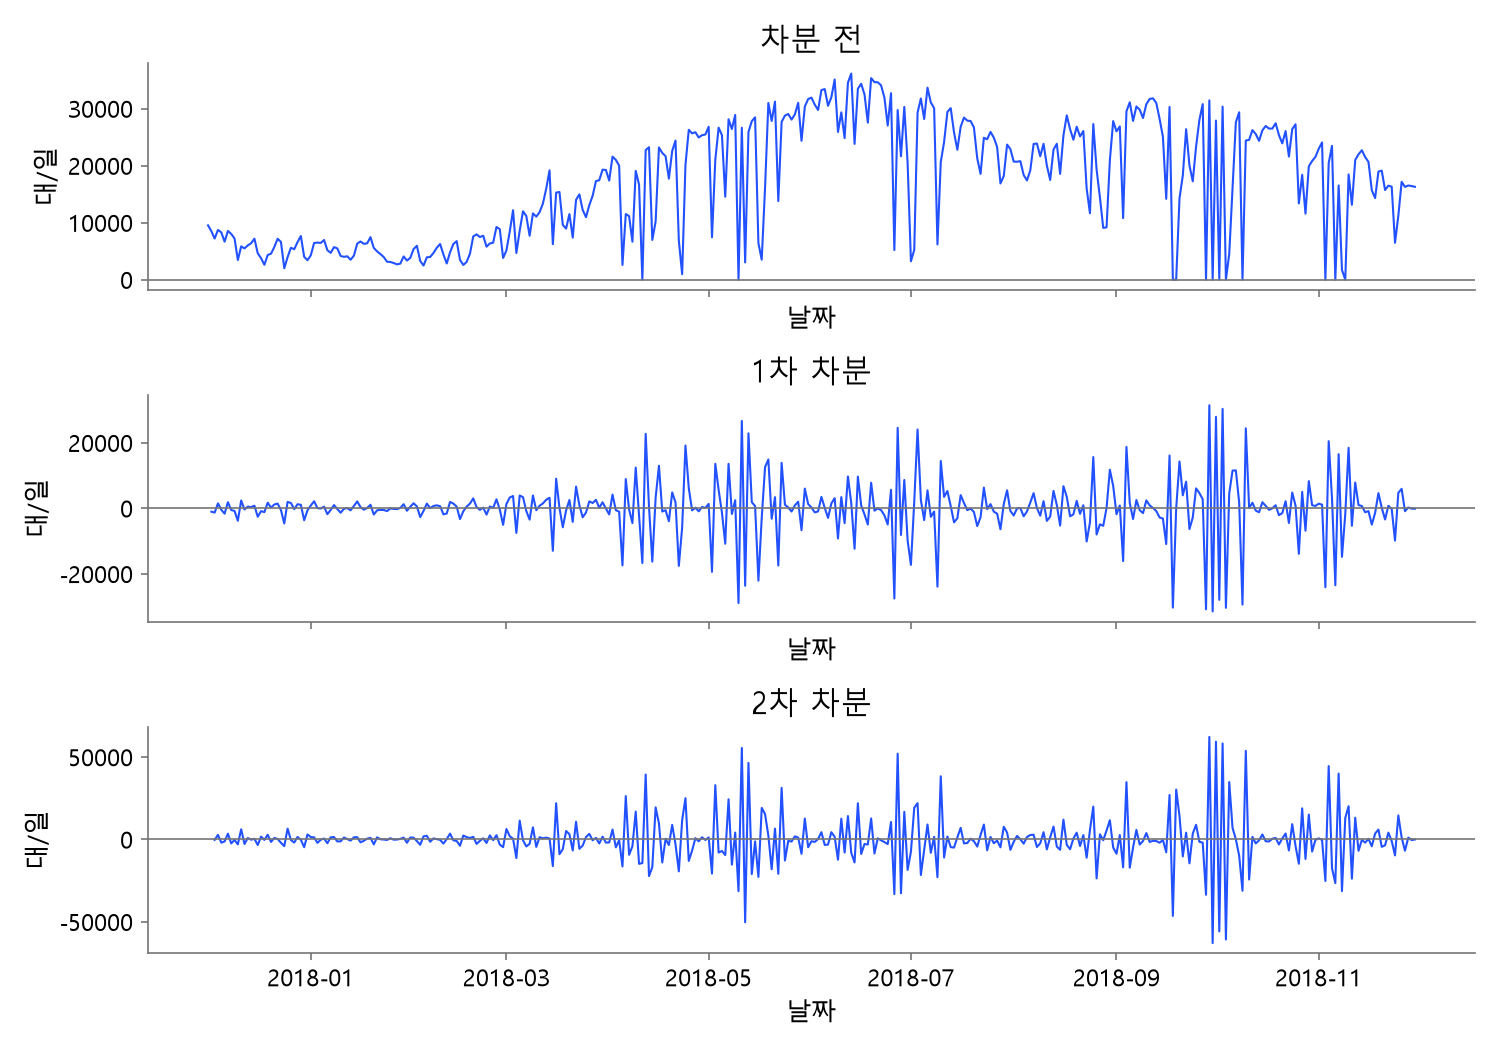

In [29]:
# 과제 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
아래 값 7개와 그림 한장을 출력할거야
1. 일 계열 1차 차분 - 시차 1 자기상관: 무차원, 소수점 아래 4자리, 양수 부호 표기
2. 일 계열 1차 차분 - 표준편차: 대/일, 소수점 아래 1자리
3. 차분 전 일 계열 - KPSS 통계량: 무차원, 소수점 아래 4자리
4. 1차 차분 일 계열 - KPSS 통계량: 무차원, 소수점 아래 4자리
5. 차분 전 일 계열 - ADF 통계량: 무차원, 소수점 아래 4자리
6. 1차 차분 일 계열 - ADF 통계량: 무차원, 소수점 아래 4자리
7. 2차 차분 일 계열 - 표준편차와 시차 1 자기상관: 대/일, 소수점 아래 1자리, 자기상관 소수점 아래 4자래
"""
# --- 여기부터 AI 코드 ---
diff1 = daily_c.diff().dropna()
diff2 = diff1.diff().dropna()

ac1 = autocorr(diff1, 1)
std1 = diff1.std()
kpss_before = kpss(daily_c, regression="c", nlags="auto")[0]
kpss_diff1 = kpss(diff1, regression="c", nlags="auto")[0]
adf_before = adfuller(daily_c, autolag="AIC")[0]
adf_diff1 = adfuller(diff1, autolag="AIC")[0]
std2 = diff2.std()
ac2 = autocorr(diff2, 1)

print(f"일 계열 1차 차분 — 시차 1 자기상관 = {ac1:+.4f}")
print(f"일 계열 1차 차분 — 표준편차 = {std1:.1f}")
print(f"차분 전 일 계열 — KPSS 통계량 = {kpss_before:.4f}")
print(f"1차 차분 일 계열 — KPSS 통계량 = {kpss_diff1:.4f}")
print(f"차분 전 일 계열 — ADF 검정통계량 = {adf_before:.4f}")
print(f"1차 차분 일 계열 — ADF 검정통계량 = {adf_diff1:.4f}")
print(f"2차 차분 일 계열 — 표준편차와 시차 1 자기상관 = {std2:.1f}, {ac2:+.4f}")

fig, axes = plt.subplots(3, 1, figsize=(FIG_W, 7), sharex=True)

for ax, series, title in zip(axes, [daily_c, diff1, diff2], ["차분 전", "1차 차분", "2차 차분"]):
    ax.plot(series.index, series.values, color=COL["파랑"], lw=1)
    ax.axhline(0, color=COL["회색"], lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("날짜")
    ax.set_ylabel("대/일")

plt.show()

(가) 차분을 통해 정상성을 만들었지만 아직 계절성 강도가 남아 있으므로 아직 예측 준비가 끝나진 않은 상태이다.

(나) 24시간 계절차분 후에도 시차 24·48 에서 자기상관이 다시 커지는 부분은 둘째 날 배울 SARIMA 모형의 계절 AR(P)·계절 MA(Q) 항이 설명하고, 그 외 짧은 시차에 남는 자기상관은 일반 AR(p)·MA(q) 항이 설명함.

(다) m=24 는 미션 1 이 같은 1 년에서 잰 계절성 강도 값 — 주기 24 는 0.5715, 주기 7 은 0.0894 — 로 정했고, 주기 24 가 추세를 뺀 변동의 절반 이상을 설명하는 반면 주기 7 은 0.1 에도 못 미친다는 그 수치 차이가 근거임